In [13]:
!pip install pyspedas

18-Dec-25 12:45:18: /Users/jwl/anaconda3/envs/pycharm_py312/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=7700) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()



# Example of FAC-Xgse matrix generation and rotation
translates from gse or gsm into FAC

X Axis = on plane defined by Xgse - Z

Second coordinate definition: Y = Z x X_gse

Third coordinate, X completes orthogonal RHS (right hand system) triad: XYZ

Note: X_gse is a unit vector pointing in direction from earth to the sun

In [14]:
from pyspedas import timespan
timespan('2007-03-23', 1, keyword='days')

In [15]:
from pyspedas.projects import themis
themis.state(probe='c')
themis.fgm(probe='c', coord='dsl', level='l2')

18-Dec-25 12:45:20: Downloading https://themis.ssl.berkeley.edu/data/themis/thc/l1/state/2007/thc_l1_state_20070323.cdf to themis_data/thc/l1/state/2007/thc_l1_state_20070323.cdf
18-Dec-25 12:45:20: Download of themis_data/thc/l1/state/2007/thc_l1_state_20070323.cdf complete, 0.372 MB in 0.5 sec (0.807 MB/sec) (transfer_normal)
18-Dec-25 12:45:20: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thc/l2/fgm/2007/
18-Dec-25 12:45:22: File is current: themis_data/thc/l2/fgm/2007/thc_l2_fgm_20070323_v01.cdf


['thc_fgs_btotal',
 'thc_fgs_dsl',
 'thc_fgl_btotal',
 'thc_fgl_dsl',
 'thc_fgh_btotal',
 'thc_fgh_dsl',
 'thc_fge_btotal',
 'thc_fge_dsl']

In [16]:
from pyspedas import tsmooth
tsmooth('thc_fgs_dsl', 601, newname='thc_fgs_dsl_sm601')

18-Dec-25 12:45:32: tsmooth was applied to: thc_fgs_dsl_sm601


['thc_fgs_dsl_sm601']

In [17]:
from pyspedas import fac_matrix_make
fac_matrix_make('thc_fgs_dsl_sm601', other_dim='Xgse', newname='thc_fgs_dsl_sm601_fac_mat')

'thc_fgs_dsl_sm601_fac_mat'

In [18]:
from pyspedas import tvector_rotate
tvector_rotate('thc_fgs_dsl_sm601_fac_mat', 'thc_fgs_dsl', newname='thc_fgs_facx')

18-Dec-25 12:45:32: Setting coordinate system for thc_fgs_facx


['thc_fgs_facx']

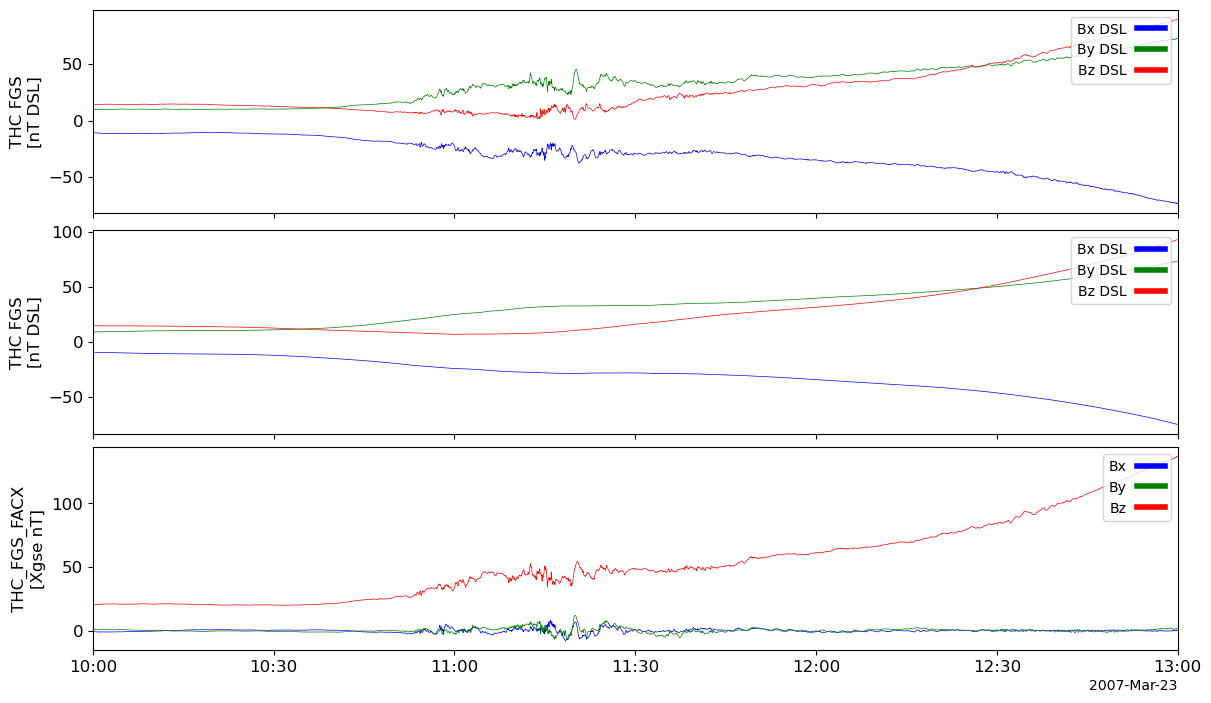

In [19]:
from pyspedas import tplot, tlimit, options
tlimit(['2007-03-23/10:00:00','2007-03-23/13:00:00'])
options('thc_fgs_facx', 'ytitle', 'THC_FGS_FACX')
options('thc_fgs_facx', 'ysubtitle', '[Xgse nT]')
options('thc_fgs_facx', 'labels', ['Bx', 'By', 'Bz'])
tplot(['thc_fgs_dsl', 'thc_fgs_dsl_sm601', 'thc_fgs_facx'])

# Example of FAC-Rgeo matrix generation and rotation
translate from geo into FAC using radial position vector

Rgeo is radial position vector, positive radialy outwards.

Second coordinate definition: Y = Z x Rgeo (eastward)

Third coordinate, X completes orthogonal RHS XYZ.

In [20]:
themis.fgm(probe='c', coord='gse', level='l2')  #coord cannot be 'dsl' here, otherwise fac_matrix_make will not work
tsmooth('thc_fgs_gse', 601, newname='thc_fgs_gse_sm601')

18-Dec-25 12:45:32: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thc/l2/fgm/2007/
18-Dec-25 12:45:34: File is current: themis_data/thc/l2/fgm/2007/thc_l2_fgm_20070323_v01.cdf
18-Dec-25 12:45:44: tsmooth was applied to: thc_fgs_gse_sm601


['thc_fgs_gse_sm601']

In [21]:
fac_matrix_make('thc_fgs_gse_sm601', other_dim='rgeo', pos_var_name='thc_pos', newname='thc_fgs_gse_sm601_fac_mat')
tvector_rotate('thc_fgs_gse_sm601_fac_mat', 'thc_fgs_gse', newname='thc_fgs_facRgeo')

18-Dec-25 12:45:44: tinterpol (linear) was applied to: thc_pos-itrp
18-Dec-25 12:45:44: ['gei', 'gse']
18-Dec-25 12:45:44: Running transformation: subgei2gse
18-Dec-25 12:45:44: Setting coordinate system for fac_mat_pos_tmp_gse
18-Dec-25 12:45:44: Output variable: fac_mat_pos_tmp_gse
18-Dec-25 12:45:44: Setting coordinate system for thc_fgs_facRgeo


['thc_fgs_facRgeo']

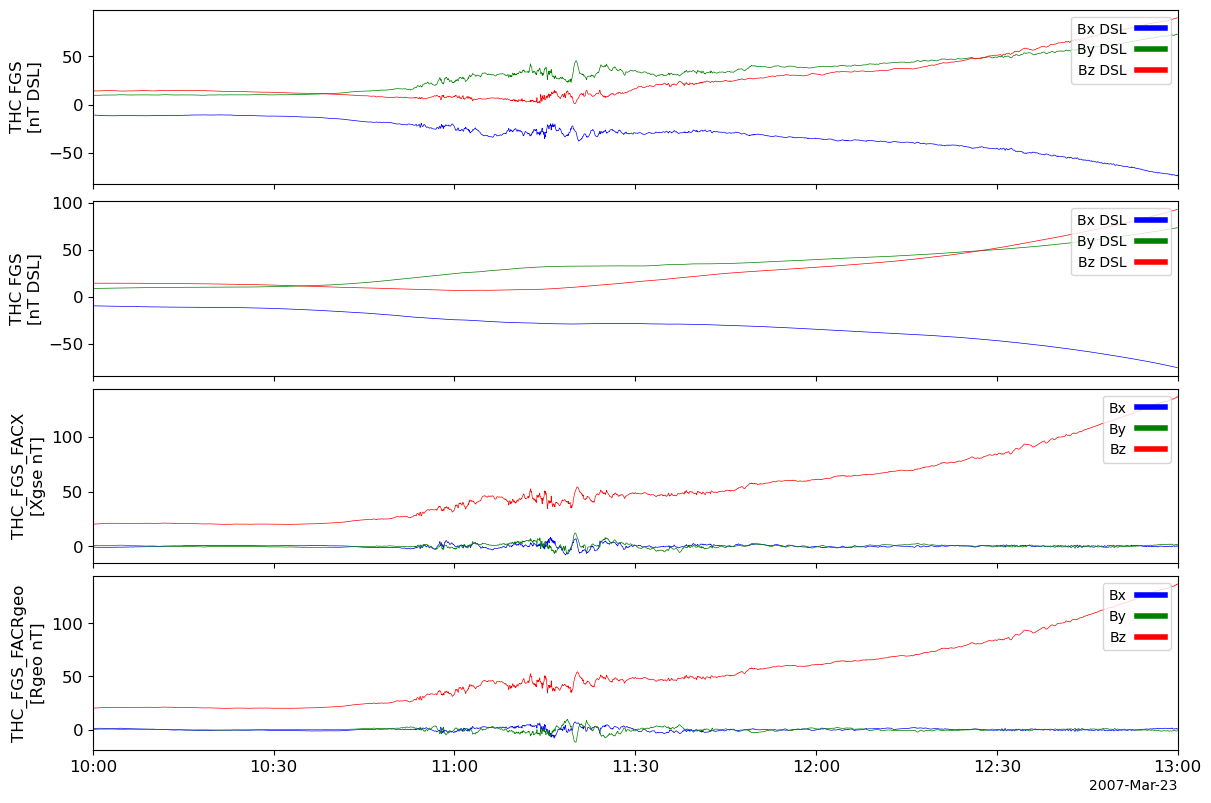

In [22]:
options('thc_fgs_facRgeo', 'ytitle', 'THC_FGS_FACRgeo')
options('thc_fgs_facRgeo', 'ysubtitle', '[Rgeo nT]')
options('thc_fgs_facRgeo', 'labels', ['Bx', 'By', 'Bz'])
tplot(['thc_fgs_dsl', 'thc_fgs_dsl_sm601', 'thc_fgs_facx', 'thc_fgs_facRgeo'])

# Example of FAC-mRgeo matrix generation and rotation
translate into FAC using radial position vector

mRgeo is radial position vector, positive radially inwards.

Second coordinate definition: Y = Z x mRgeo (westward)

Third coordinate, X completes orthogonal RHS XYZ.

In [23]:
themis.fgm(probe='c', coord='gse', level='l2')  #coord cannot be 'dsl' here, otherwise fac_matrix_make will not work
tsmooth('thc_fgs_gse', 601, newname='thc_fgs_gse_sm601')

18-Dec-25 12:45:45: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thc/l2/fgm/2007/
18-Dec-25 12:45:46: File is current: themis_data/thc/l2/fgm/2007/thc_l2_fgm_20070323_v01.cdf
18-Dec-25 12:45:57: tsmooth was applied to: thc_fgs_gse_sm601


['thc_fgs_gse_sm601']

In [24]:
fac_matrix_make('thc_fgs_gse_sm601', other_dim='mRgeo', pos_var_name='thc_pos', newname='thc_fgs_gse_sm601_fac_mat')
tvector_rotate('thc_fgs_gse_sm601_fac_mat', 'thc_fgs_gse', newname='thc_fgs_facmRgeo')

18-Dec-25 12:45:57: tinterpol (linear) was applied to: thc_pos-itrp
18-Dec-25 12:45:57: ['gei', 'gse']
18-Dec-25 12:45:57: Running transformation: subgei2gse
18-Dec-25 12:45:57: Setting coordinate system for fac_mat_pos_tmp_gse
18-Dec-25 12:45:57: Output variable: fac_mat_pos_tmp_gse
18-Dec-25 12:45:57: Setting coordinate system for thc_fgs_facmRgeo


['thc_fgs_facmRgeo']

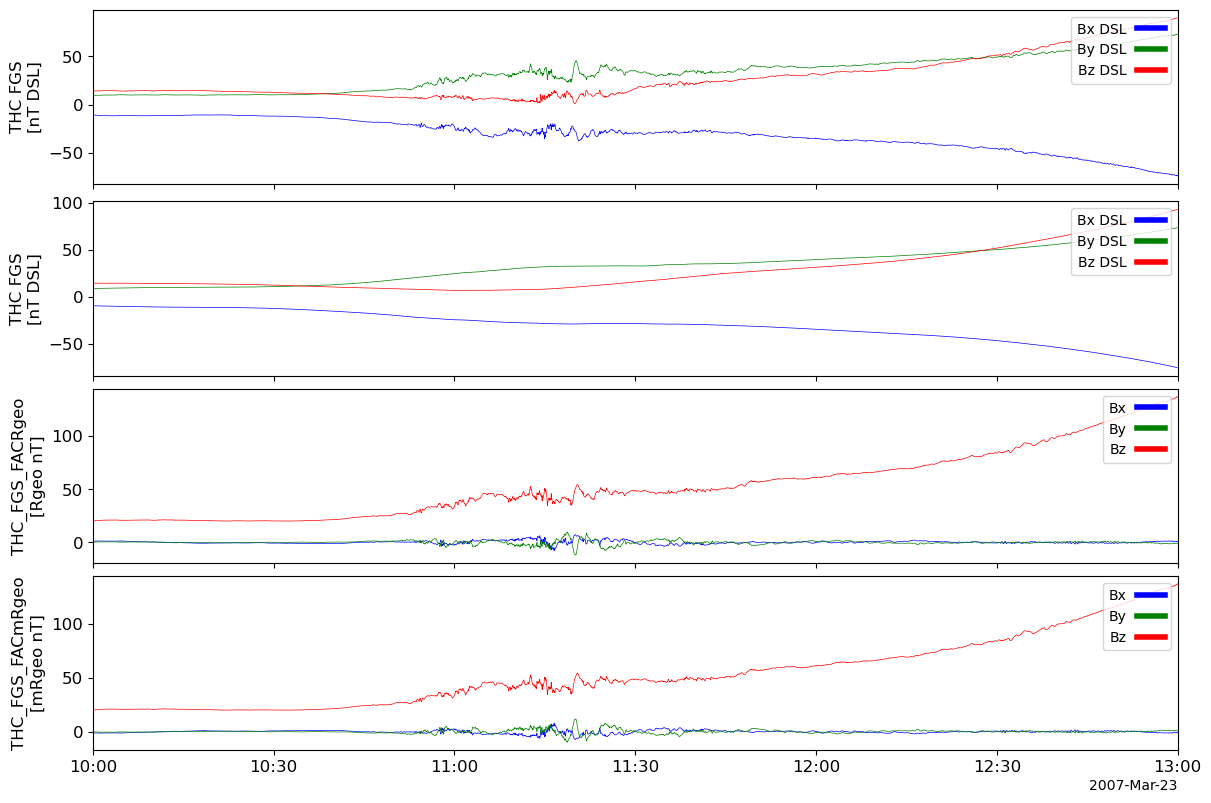

In [25]:
options('thc_fgs_facmRgeo', 'ytitle', 'THC_FGS_FACmRgeo')
options('thc_fgs_facmRgeo', 'ysubtitle', '[mRgeo nT]')
options('thc_fgs_facmRgeo', 'labels', ['Bx', 'By', 'Bz'])
tplot(['thc_fgs_dsl', 'thc_fgs_dsl_sm601', 'thc_fgs_facRgeo', 'thc_fgs_facmRgeo'])

# Example of FAC-Phigeo matrix generation and rotation
translate into FAC using azimuthal position vector

Phigeo is the azimuthal geo position vector, positive Eastward

First coordinate definition: X = Phigeo x Z (positive outwards)

Second coordinate, Y ~ Phigeo (eastward) completes orthogonal RHS XYZ

In [26]:
themis.fgm(probe='c', coord='gse', level='l2')  #coord cannot be 'dsl' here, otherwise fac_matrix_make will not work
tsmooth('thc_fgs_gse', 601, newname='thc_fgs_gse_sm601')

18-Dec-25 12:45:58: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thc/l2/fgm/2007/
18-Dec-25 12:45:59: File is current: themis_data/thc/l2/fgm/2007/thc_l2_fgm_20070323_v01.cdf
18-Dec-25 12:46:10: tsmooth was applied to: thc_fgs_gse_sm601


['thc_fgs_gse_sm601']

In [27]:
fac_matrix_make('thc_fgs_gse_sm601', other_dim='phigeo', pos_var_name='thc_pos', newname='thc_fgs_gse_sm601_fac_mat')
tvector_rotate('thc_fgs_gse_sm601_fac_mat', 'thc_fgs_gse', newname='thc_fgs_facPhigeo')

18-Dec-25 12:46:10: tinterpol (linear) was applied to: thc_pos-itrp
18-Dec-25 12:46:10: ['gei', 'gse']
18-Dec-25 12:46:10: Running transformation: subgei2gse
18-Dec-25 12:46:10: Setting coordinate system for fac_mat_pos_tmp_gse
18-Dec-25 12:46:10: Output variable: fac_mat_pos_tmp_gse
18-Dec-25 12:46:10: Setting coordinate system for thc_fgs_facPhigeo


['thc_fgs_facPhigeo']

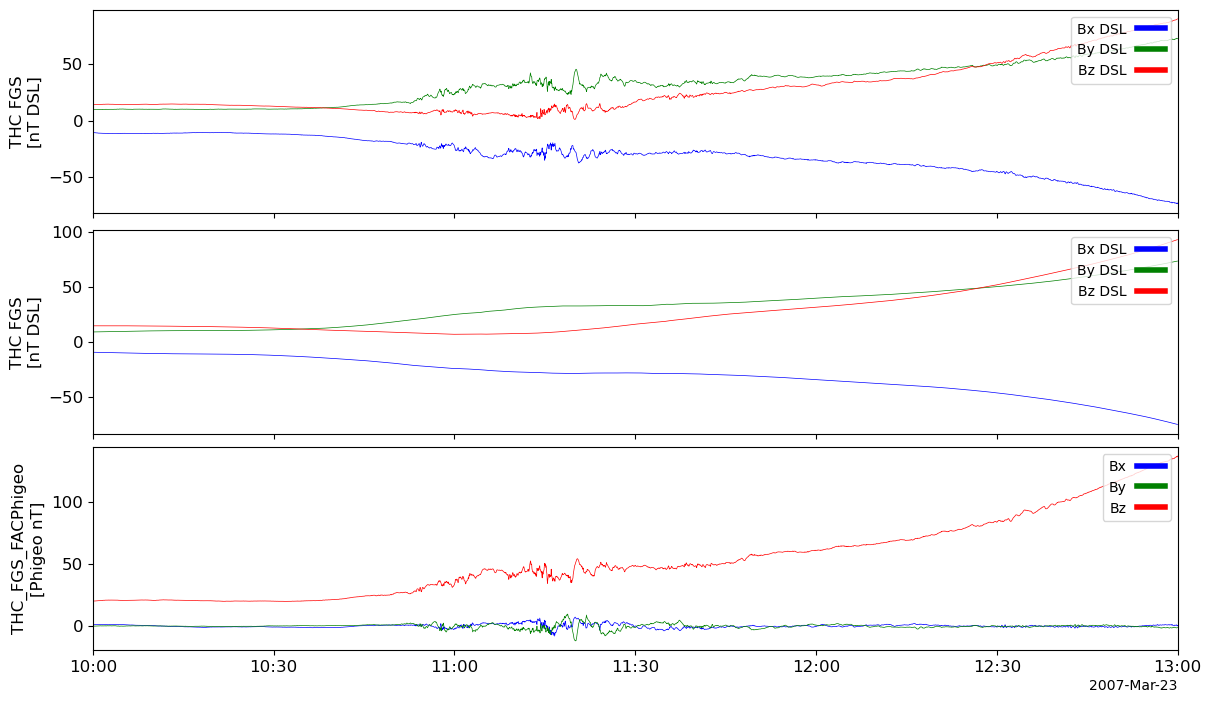

In [28]:
options('thc_fgs_facPhigeo', 'ytitle', 'THC_FGS_FACPhigeo')
options('thc_fgs_facPhigeo', 'ysubtitle', '[Phigeo nT]')
options('thc_fgs_facPhigeo', 'labels', ['Bx', 'By', 'Bz'])
tplot(['thc_fgs_dsl', 'thc_fgs_dsl_sm601', 'thc_fgs_facPhigeo'])

# Example of FAC-mPhigeo matrix generation and rotation

translate into FAC using azimuthal position vector

mPhigeo is minus the azimuthal geo position vector; positive Westward

First coordinate definition: X = mPhigeo x Z (positive inwards)

Second coordinate, Y ~ mPhigeo (Westward) completes orthogonal RHS XYZ

In [29]:
themis.fgm(probe='c', coord='gse', level='l2')  #coord cannot be 'dsl' here, otherwise fac_matrix_make will not work
tsmooth('thc_fgs_gse', 601, newname='thc_fgs_gse_sm601')

18-Dec-25 12:46:10: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thc/l2/fgm/2007/
18-Dec-25 12:46:11: File is current: themis_data/thc/l2/fgm/2007/thc_l2_fgm_20070323_v01.cdf
18-Dec-25 12:46:22: tsmooth was applied to: thc_fgs_gse_sm601


['thc_fgs_gse_sm601']

In [30]:
fac_matrix_make('thc_fgs_gse_sm601', other_dim='mPhigeo', pos_var_name='thc_pos', newname='thc_fgs_gse_sm601_fac_mat')
tvector_rotate('thc_fgs_gse_sm601_fac_mat', 'thc_fgs_gse', newname='thc_fgs_facmPhigeo')

18-Dec-25 12:46:22: tinterpol (linear) was applied to: thc_pos-itrp
18-Dec-25 12:46:22: ['gei', 'gse']
18-Dec-25 12:46:22: Running transformation: subgei2gse
18-Dec-25 12:46:22: Setting coordinate system for fac_mat_pos_tmp_gse
18-Dec-25 12:46:22: Output variable: fac_mat_pos_tmp_gse
18-Dec-25 12:46:22: Setting coordinate system for thc_fgs_facmPhigeo


['thc_fgs_facmPhigeo']

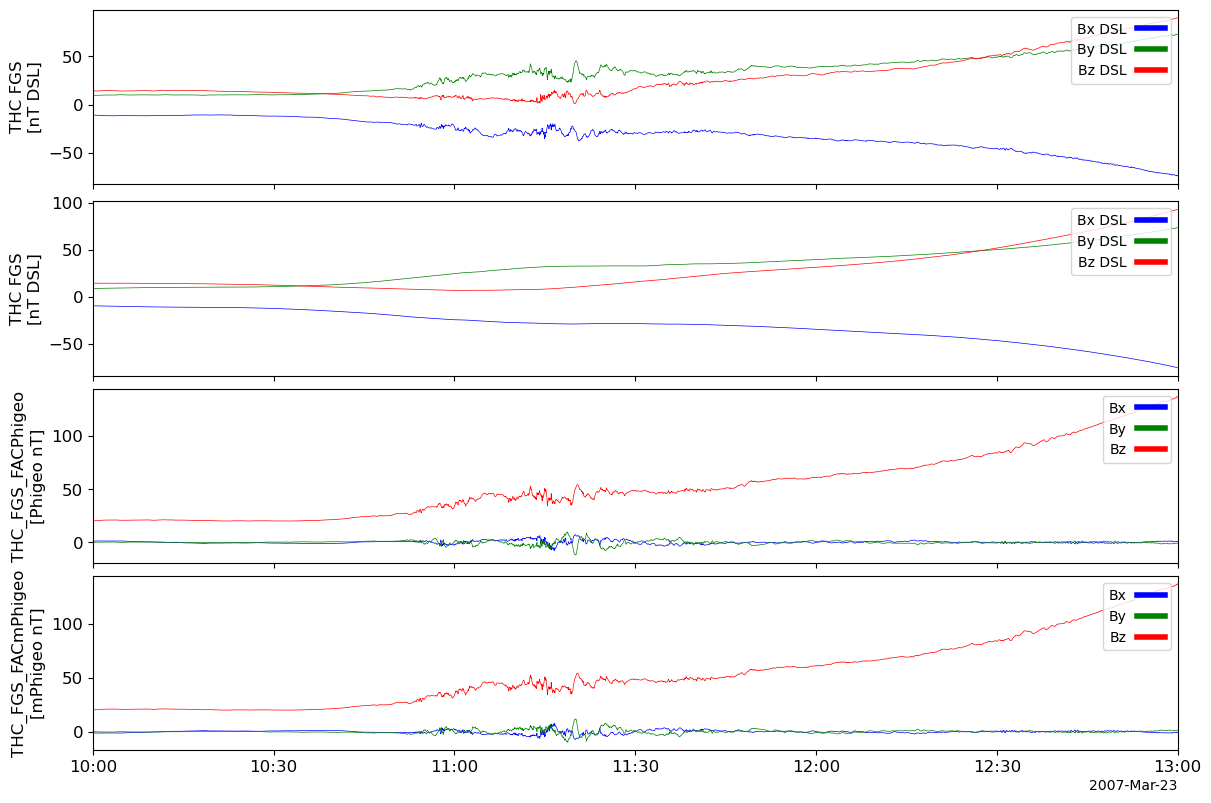

In [31]:
options('thc_fgs_facmPhigeo', 'ytitle', 'THC_FGS_FACmPhigeo')
options('thc_fgs_facmPhigeo', 'ysubtitle', '[mPhigeo nT]')
options('thc_fgs_facmPhigeo', 'labels', ['Bx', 'By', 'Bz'])
tplot(['thc_fgs_dsl', 'thc_fgs_dsl_sm601', 'thc_fgs_facPhigeo', 'thc_fgs_facmPhigeo'])

# Example of FAC-Phism matrix generation and rotation

translate into FAC using azimuthal Solar Magnetospheric vector.

Phism is "phi" vector of satellite position in SM coordinates.

Y Axis = on plane defined by Phism-Z, normal to Z

Second coordinate definition: X = Phism x Z

Third completes orthogonal RHS XYZ

In [32]:
themis.fgm(probe='c', coord='gse', level='l2')  #coord cannot be 'dsl' here, otherwise fac_matrix_make will not work
tsmooth('thc_fgs_gse', 601, newname='thc_fgs_gse_sm601')

18-Dec-25 12:46:22: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thc/l2/fgm/2007/
18-Dec-25 12:46:24: File is current: themis_data/thc/l2/fgm/2007/thc_l2_fgm_20070323_v01.cdf
18-Dec-25 12:46:34: tsmooth was applied to: thc_fgs_gse_sm601


['thc_fgs_gse_sm601']

In [33]:
fac_matrix_make('thc_fgs_gse_sm601', other_dim='Phism', pos_var_name='thc_pos', newname='thc_fgs_gse_sm601_fac_mat')
tvector_rotate('thc_fgs_gse_sm601_fac_mat', 'thc_fgs_gse', newname='thc_fgs_facPhism')

18-Dec-25 12:46:34: ['gei', 'gse', 'gsm', 'sm']
18-Dec-25 12:46:34: Running transformation: subgei2gse
18-Dec-25 12:46:34: Running transformation: subgse2gsm
18-Dec-25 12:46:34: Running transformation: subgsm2sm
18-Dec-25 12:46:34: Setting coordinate system for thc_pos-sm
18-Dec-25 12:46:34: Output variable: thc_pos-sm
18-Dec-25 12:46:34: tinterpol (linear) was applied to: thc_pos-sm-itrp
18-Dec-25 12:46:34: ['sm', 'gsm', 'gse', 'gei']
18-Dec-25 12:46:35: Running transformation: subsm2gsm
18-Dec-25 12:46:35: Running transformation: subgsm2gse
18-Dec-25 12:46:35: Running transformation: subgse2gei
18-Dec-25 12:46:35: ['gei', 'gse']
18-Dec-25 12:46:35: Running transformation: subgei2gse
18-Dec-25 12:46:35: Setting coordinate system for fac_mat_pos_tmp_gse
18-Dec-25 12:46:35: Output variable: fac_mat_pos_tmp_gse
18-Dec-25 12:46:35: Setting coordinate system for thc_fgs_facPhism


['thc_fgs_facPhism']

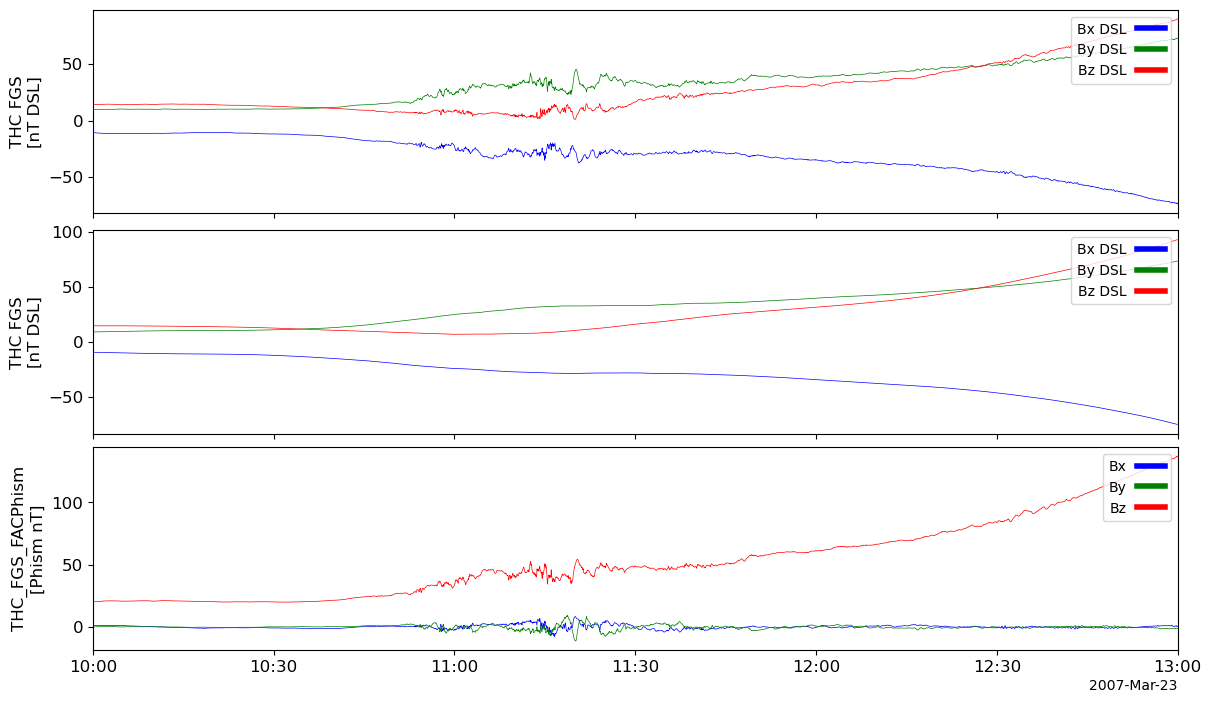

In [34]:
options('thc_fgs_facPhism', 'ytitle', 'THC_FGS_FACPhism')
options('thc_fgs_facPhism', 'ysubtitle', '[Phism nT]')
options('thc_fgs_facPhism', 'labels', ['Bx', 'By', 'Bz'])
tplot(['thc_fgs_dsl', 'thc_fgs_dsl_sm601', 'thc_fgs_facPhism'])

# Example of FAC-mPhism matrix generation and rotation

translate into FAC using azimuthal Solar Magnetospheric vector.

mPhism is minus "phi" vector of satellite position in SM coordinates.

Y Axis = on plane defined by Phism-Z, normal to Z

Second coordinate definition: X = mPhism x Z

Third completes orthogonal RHS XYZ

In [35]:
themis.fgm(probe='c', coord='gse', level='l2')  #coord cannot be 'dsl' here, otherwise fac_matrix_make will not work
tsmooth('thc_fgs_gse', 601, newname='thc_fgs_gse_sm601')

18-Dec-25 12:46:35: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thc/l2/fgm/2007/
18-Dec-25 12:46:36: File is current: themis_data/thc/l2/fgm/2007/thc_l2_fgm_20070323_v01.cdf
18-Dec-25 12:46:47: tsmooth was applied to: thc_fgs_gse_sm601


['thc_fgs_gse_sm601']

In [36]:
fac_matrix_make('thc_fgs_gse_sm601', other_dim='mPhism', pos_var_name='thc_pos', newname='thc_fgs_gse_sm601_fac_mat')
tvector_rotate('thc_fgs_gse_sm601_fac_mat', 'thc_fgs_gse', newname='thc_fgs_facmPhism')

18-Dec-25 12:46:47: ['gei', 'gse', 'gsm', 'sm']
18-Dec-25 12:46:47: Running transformation: subgei2gse
18-Dec-25 12:46:47: Running transformation: subgse2gsm
18-Dec-25 12:46:47: Running transformation: subgsm2sm
18-Dec-25 12:46:47: Setting coordinate system for thc_pos-sm
18-Dec-25 12:46:47: Output variable: thc_pos-sm
18-Dec-25 12:46:47: tinterpol (linear) was applied to: thc_pos-sm-itrp
18-Dec-25 12:46:47: ['sm', 'gsm', 'gse', 'gei']
18-Dec-25 12:46:47: Running transformation: subsm2gsm
18-Dec-25 12:46:47: Running transformation: subgsm2gse
18-Dec-25 12:46:47: Running transformation: subgse2gei
18-Dec-25 12:46:47: ['gei', 'gse']
18-Dec-25 12:46:47: Running transformation: subgei2gse
18-Dec-25 12:46:47: Setting coordinate system for fac_mat_pos_tmp_gse
18-Dec-25 12:46:47: Output variable: fac_mat_pos_tmp_gse
18-Dec-25 12:46:47: Setting coordinate system for thc_fgs_facmPhism


['thc_fgs_facmPhism']

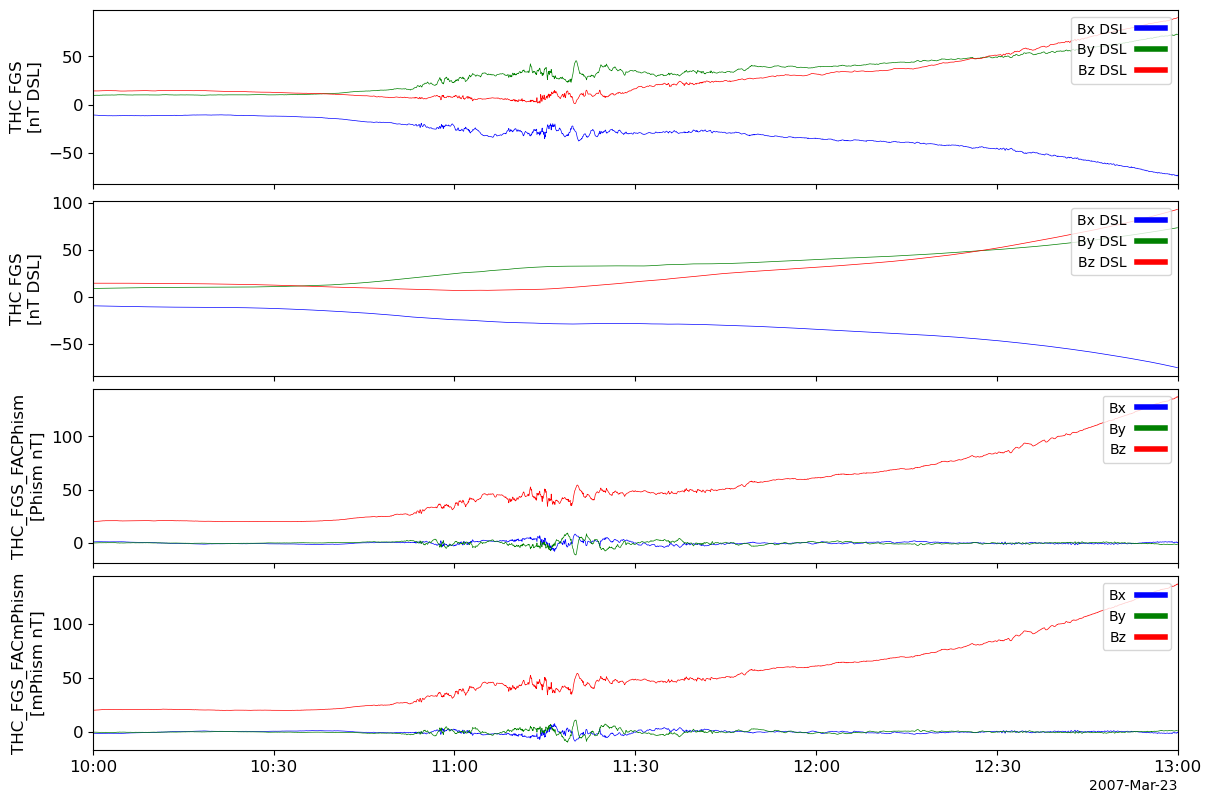

In [37]:
options('thc_fgs_facmPhism', 'ytitle', 'THC_FGS_FACmPhism')
options('thc_fgs_facmPhism', 'ysubtitle', '[mPhism nT]')
options('thc_fgs_facmPhism', 'labels', ['Bx', 'By', 'Bz'])
tplot(['thc_fgs_dsl', 'thc_fgs_dsl_sm601', 'thc_fgs_facPhism', 'thc_fgs_facmPhism'])

# Example of FAC-Ygsm matrix generation and rotation

translate into FAC using cartesian Ygsm position as other dimension.

Y Axis on plane defined by Ygsm and Z

First coordinate definition: X = Ygsm x Z

Third completes orthogonal RHS XYZ

In [38]:
themis.fgm(probe='c', coord='gse', level='l2')  #coord cannot be 'dsl' here, otherwise fac_matrix_make will not work
tsmooth('thc_fgs_gse', 601, newname='thc_fgs_gse_sm601')

18-Dec-25 12:46:47: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thc/l2/fgm/2007/
18-Dec-25 12:46:49: File is current: themis_data/thc/l2/fgm/2007/thc_l2_fgm_20070323_v01.cdf
18-Dec-25 12:46:59: tsmooth was applied to: thc_fgs_gse_sm601


['thc_fgs_gse_sm601']

In [39]:
fac_matrix_make('thc_fgs_gse_sm601', other_dim='ygsm', pos_var_name='thc_pos', newname='thc_fgs_gse_sm601_fac_mat')
tvector_rotate('thc_fgs_gse_sm601_fac_mat', 'thc_fgs_gse', newname='thc_fgs_facy')

18-Dec-25 12:46:59: ['gsm', 'gse']
18-Dec-25 12:46:59: Running transformation: subgsm2gse
18-Dec-25 12:46:59: Setting coordinate system for thc_fgs_facy


['thc_fgs_facy']

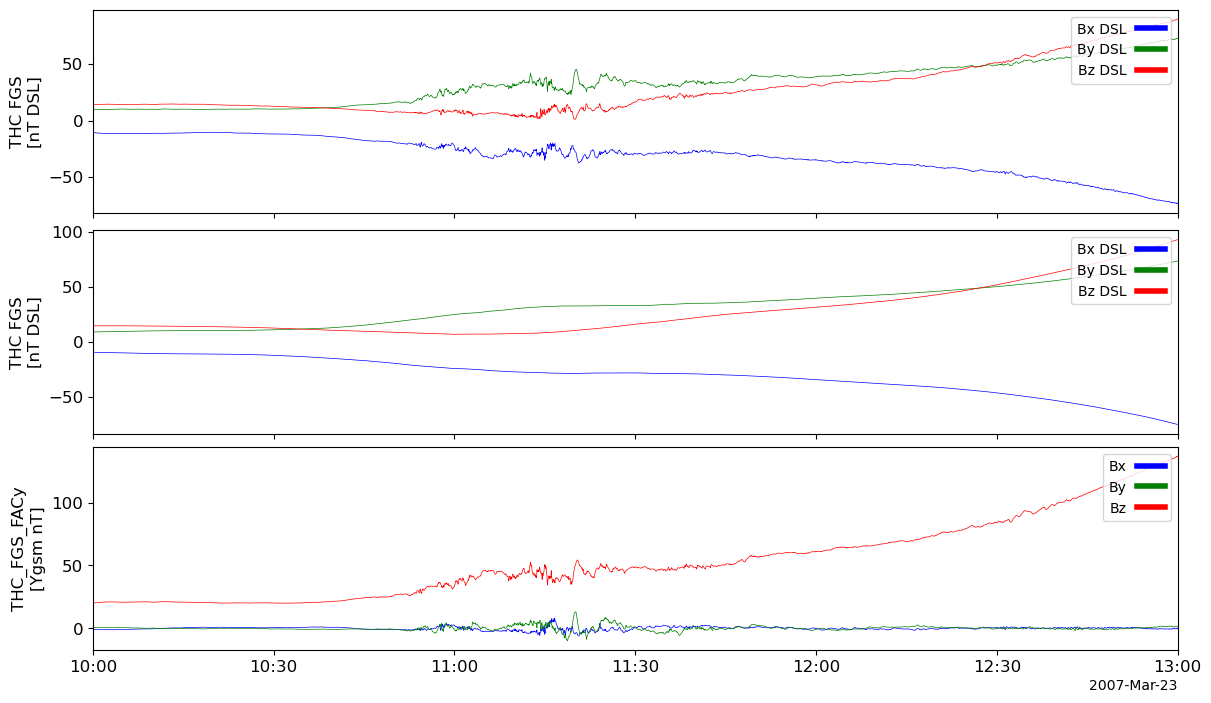

In [40]:
options('thc_fgs_facy', 'ytitle', 'THC_FGS_FACy')
options('thc_fgs_facy', 'ysubtitle', '[Ygsm nT]')
options('thc_fgs_facy', 'labels', ['Bx', 'By', 'Bz'])
tplot(['thc_fgs_dsl', 'thc_fgs_dsl_sm601', 'thc_fgs_facy'])